<a href="https://colab.research.google.com/github/massivetriceps/AI/blob/main/AAME_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving AAME.csv to AAME.csv


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
import matplotlib.pyplot as plt


In [9]:
df_cleaned = df.drop(columns=['Date', 'Volume']).dropna().reset_index(drop=True)

In [10]:
print(df_cleaned.head())

   Open  High   Low  Close  Adj Close
0   0.0  4.05  3.85   3.85   3.213167
1   0.0  4.00  3.80   3.80   3.171437
2   0.0  4.05  3.85   3.85   3.213167
3   0.0  4.00  3.80   3.80   3.171437
4   0.0  3.95  3.75   3.75   3.129709


In [11]:
df = pd.read_csv('AAME.csv')
data = df[['Open', 'High', 'Low', 'Close']].copy()

In [12]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [13]:
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i - window_size:i])
        y.append(data[i, 3])
    return np.array(X), np.array(y)

window_size = 60
X, y = create_sequences(data_scaled, window_size)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [14]:
model = Sequential()
model.add(SimpleRNN(units=50, activation='tanh', input_shape=(X.shape[1], X.shape[2])))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


251/251 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0258 - val_loss: 7.7221e-05
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 1.4660e-04 - val_loss: 4.9583e-05
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 1.2011e-04 - val_loss: 5.3460e-05
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 1.1136e-04 - val_loss: 4.5490e-05
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 1.3027e-04 - val_loss: 4.3390e-05
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 1.2513e-04 - val_loss: 4.6993e-05
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 1.2642e-04 - val_loss: 5.9761e-05
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 1.1088e-04 - val_loss: 6.1426e-05
Epoch 9/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 1.1096e-04 - val_loss: 9.2102e-05
Epoch 10/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1.0953e-04 - val_loss: 5.2568e-05


In [7]:
predicted = model.predict(X_test)
predicted_full = np.zeros((predicted.shape[0], 4))
actual_full = np.zeros((y_test.shape[0], 4))
predicted_full[:, 3] = predicted[:, 0]
actual_full[:, 3] = y_test

predicted_prices = scaler.inverse_transform(predicted_full)[:, 3]
actual_prices = scaler.inverse_transform(actual_full)[:, 3]

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


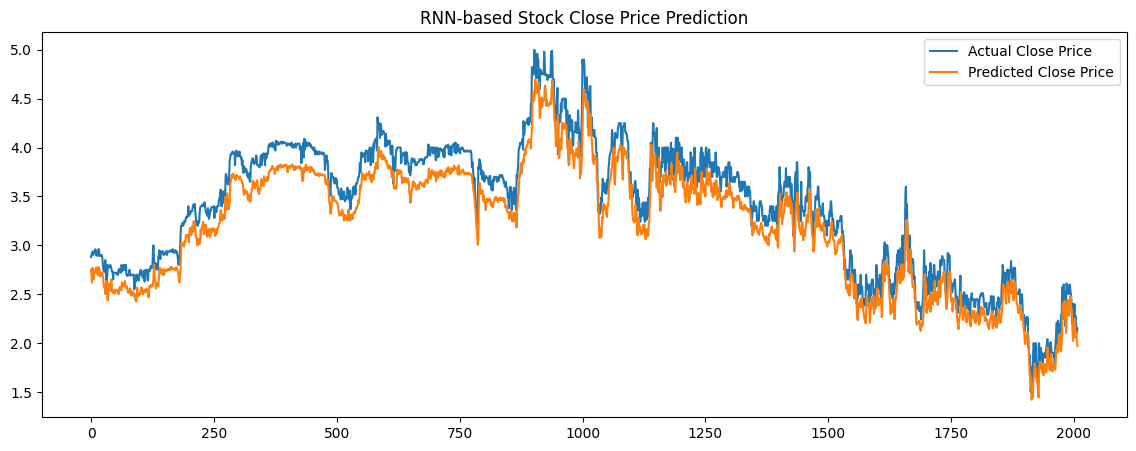

In [8]:
plt.figure(figsize=(14,5))
plt.plot(actual_prices, label='Actual Close Price')
plt.plot(predicted_prices, label='Predicted Close Price')
plt.legend()
plt.title("RNN-based Stock Close Price Prediction")
plt.show()